In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import activations as act

In [10]:


def generate_linear_dataset(n_samples=20):
    np.random.seed(0)  # so you get same values each time
    X = np.random.rand(n_samples, 2) * 2 - 1  # random points in [-1, 1]
    # True weights for fake boundary: say x1 + x2 = 0 → class 1 if sum > 0
    y = (X[:, 0] + X[:, 1] > 0).astype(int)
    return X, y

# Test this:
X_train, y_train = generate_linear_dataset(40)
X_test, y_test = X_train, y_train  # simple test = train


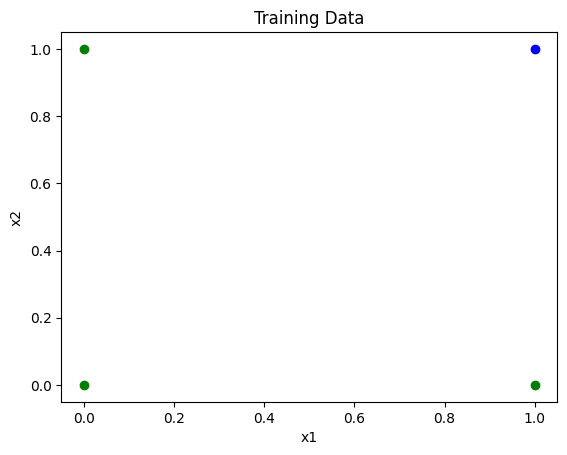

In [21]:
plt.scatter(X_train[y_train==0,0], X_train[y_train==0,1], color='green', label='Class 0')
plt.scatter(X_train[y_train==1,0], X_train[y_train==1,1], color='blue', label='Class 1')
plt.xlabel("x1"); plt.ylabel("x2")
plt.title("Training Data")
plt.show()

In [22]:
num_samples, num_features = X_train.shape
w = np.zeros(num_features)
b = 0

In [23]:
max_iter = 1000
lr = 0.1

In [24]:
for iterations in range(max_iter):
    for idx, x_i in enumerate(X_train):
        v = np.dot(x_i,w)+b
        y_hat = act.heavyside(v)
        w+=lr*(y_train[idx]-y_hat)*x_i
        b+=lr*(y_train[idx]-y_hat)

In [25]:
y_pred = act.heavyside(np.dot(X_test,w)+b)
error = np.sum(y_pred-y_test)**2/num_samples
print(f"Test Error: {error}")


Test Error: 0.0


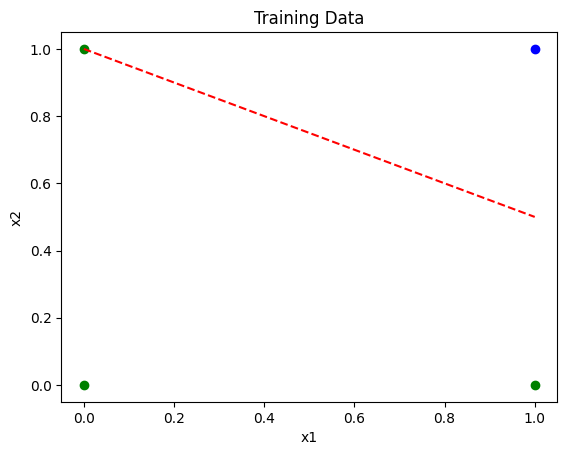

In [26]:
plt.scatter(X_train[y_train==0,0], X_train[y_train==0,1], color='green', label='Class 0')
plt.scatter(X_train[y_train==1,0], X_train[y_train==1,1], color='blue', label='Class 1')
x_values = np.linspace(X_train.min(), X_train.max(), 100)
y_values = -(w[0]*x_values + b)/w[1]
plt.plot(x_values, y_values, '--', color='red')
plt.xlabel("x1"); plt.ylabel("x2")
plt.title("Training Data")
plt.show()